# 02e - HLDA Eigenvalue to Tm Baseline

Small baseline notebook: use the saved CSVs only, fit a linear model from `hlda_evalue` to `Tm`, evaluate on held-out mutants, and aggregate repeated-split performance for comparison against the CV-based `Tm` decoders.


In [100]:
# Requires: pip install -e .

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from course_project.peptide import load_target_table
from course_project.peptide_tm import prediction_stats



### Config


In [101]:
peptide_dir = Path('../data/peptide')
tm_csv = peptide_dir / 'Tm.csv'
mfpt_csv = peptide_dir / 'mfpt_slice_thr0p34_tF0p25_tU0p57.csv'
evalue_csv = peptide_dir / 'hlda_evalues_thr0p34_tF0p25_tU0p57.csv'
per_threshold_evalue_csv = peptide_dir / 'per_mutant_hlda_EV_indexed.csv'

target_metric = 'Tm'
feature_col = 'EV'
num_experiments = 10
base_seed = 657567675657
use_best_threshold_from_scan = True
default_thr_f = 0.31
default_thr_uf = 0.75

# Match the currently selected 02c setup directly.
train_count = 12
val_count = 10
non_test_count = train_count + val_count

target_df = load_target_table(tm_csv, mfpt_csv, evalue_csv)
tm_df = target_df[['mutant', target_metric]].copy()
tm_df['mutant'] = tm_df['mutant'].astype(str).str.strip()
per_threshold_df = pd.read_csv(per_threshold_evalue_csv)
per_threshold_df['Mutant'] = per_threshold_df['Mutant'].astype(str).str.strip()
all_mutants = sorted(tm_df['mutant'].unique().tolist())
test_count = len(all_mutants) - non_test_count

print(json.dumps({
    'target_metric': target_metric,
    'num_experiments': num_experiments,
    'per_threshold_rows': int(len(per_threshold_df)),
    'n_mutants_with_tm': int(len(tm_df)),
    'train_count': train_count,
    'val_count': val_count,
    'non_test_count': non_test_count,
    'test_count': test_count,
}, indent=2))



{
  "target_metric": "Tm",
  "num_experiments": 10,
  "per_threshold_rows": 15190,
  "n_mutants_with_tm": 37,
  "train_count": 12,
  "val_count": 10,
  "non_test_count": 22,
  "test_count": 15
}


### Helpers


In [102]:
def fit_linear_model(train_df, feature_col, target_col):
    x = train_df[feature_col].to_numpy(dtype=float)
    y = train_df[target_col].to_numpy(dtype=float)
    X = np.column_stack([np.ones(len(x)), x])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return coef


def predict_linear_model(df, coef, feature_col, target_col):
    x = df[feature_col].to_numpy(dtype=float)
    X = np.column_stack([np.ones(len(x)), x])
    pred = X @ coef
    out = df[['mutant', target_col, feature_col]].copy()
    out[f'pred_{target_col}'] = pred
    return out

345345
def split_mutants(df, train_count, seed):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(df))
    train_idx = perm[:train_count]
    test_idx = perm[train_count:]
    train_df = df.iloc[train_idx].sort_values('mutant').reset_index(drop=True)
    test_df = df.iloc[test_idx].sort_values('mutant').reset_index(drop=True)
    return train_df, test_df



def split_mutants_three_way(df, train_count, val_count, seed):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(df))
    train_idx = perm[:train_count]
    val_idx = perm[train_count:train_count + val_count]
    test_idx = perm[train_count + val_count:]
    train_df = df.iloc[train_idx].sort_values('mutant').reset_index(drop=True)
    val_df = df.iloc[val_idx].sort_values('mutant').reset_index(drop=True)
    test_df = df.iloc[test_idx].sort_values('mutant').reset_index(drop=True)
    return train_df, val_df, test_df


### Threshold Scan


In [103]:
def build_threshold_scan_df(tm_df, per_threshold_df, target_metric):
    rows = []
    for (thr_f, thr_uf), g in per_threshold_df.groupby(['Thr_F', 'Thr_UF']):
        merged = tm_df.merge(g[['Mutant', 'EV']], left_on='mutant', right_on='Mutant', how='inner').dropna()
        if len(merged) < 3:
            continue
        stats_df = merged[['mutant', target_metric]].copy()
        stats_df[f'pred_{target_metric}'] = merged['EV'].to_numpy(dtype=float)
        stats = prediction_stats(stats_df, target_metric)
        rows.append({
            'Thr_F': float(thr_f),
            'Thr_UF': float(thr_uf),
            'n': int(len(merged)),
            **stats,
            'abs_pearson': abs(float(stats['pearson'])),
            'abs_spearman': abs(float(stats['spearman'])),
        })
    return pd.DataFrame(rows).sort_values(['abs_pearson', 'abs_spearman'], ascending=[False, False]).reset_index(drop=True)


def build_baseline_df_for_threshold(tm_df, per_threshold_df, thr_f, thr_uf, target_metric):
    threshold_ev_df = per_threshold_df[(per_threshold_df['Thr_F'] == thr_f) & (per_threshold_df['Thr_UF'] == thr_uf)].copy()
    out = tm_df.merge(threshold_ev_df[['Mutant', 'EV']], left_on='mutant', right_on='Mutant', how='inner').dropna().reset_index(drop=True)
    return out[['mutant', target_metric, 'EV']].copy()

threshold_scan_df = build_threshold_scan_df(tm_df, per_threshold_df, target_metric)
scan_display_cols = ['Thr_F', 'Thr_UF', 'n', 'pearson', 'pearson_p', 'spearman', 'spearman_p']
print('Top threshold pairs by absolute raw Tm correlation:')
display(threshold_scan_df[scan_display_cols].head(15).round(4))

if use_best_threshold_from_scan:
    best_threshold_row = threshold_scan_df.iloc[0]
    selected_thr_f = float(best_threshold_row['Thr_F'])
    selected_thr_uf = float(best_threshold_row['Thr_UF'])
else:
    selected_thr_f = float(default_thr_f)
    selected_thr_uf = float(default_thr_uf)

baseline_df = build_baseline_df_for_threshold(tm_df, per_threshold_df, selected_thr_f, selected_thr_uf, target_metric)
all_mutants = baseline_df['mutant'].tolist()
test_count = len(all_mutants) - train_count
print(json.dumps({
    'selected_thr_f': selected_thr_f,
    'selected_thr_uf': selected_thr_uf,
    'baseline_mutants': len(all_mutants),
    'test_count': test_count,
}, indent=2))
baseline_df.head()



Top threshold pairs by absolute raw Tm correlation:


,Thr_F,Thr_UF,n,pearson,pearson_p,spearman,spearman_p
0,0.31,0.75,37,0.6449,0.0000,0.5932,0.0001
1,0.33,0.75,37,0.6414,0.0000,0.5760,0.0002
2,0.31,0.77,37,0.6371,0.0000,0.5819,0.0002
3,0.33,0.77,37,0.6316,0.0000,0.5723,0.0002
4,0.33,0.71,37,0.6314,0.0000,0.5979,0.0001
5,0.33,0.73,37,0.6293,0.0000,0.6032,0.0001
6,0.31,0.71,37,0.6286,0.0000,0.6066,0.0001
7,0.31,0.73,37,0.6281,0.0000,0.5871,0.0001
8,0.35,0.75,37,0.6174,0.0000,0.5498,0.0004
9,0.29,0.75,37,0.6171,0.0000,0.5876,0.0001


{
  "selected_thr_f": 0.31,
  "selected_thr_uf": 0.75,
  "baseline_mutants": 37,
  "test_count": 25
}


,mutant,Tm,EV
0,WT,407.0,14083.451190
1,D2N,420.0,15303.283388
2,D2A,394.0,12748.961869
3,Y9E,290.0,5977.556001
4,T7Q,403.0,17376.543571


### Global Raw Correlation


,Thr_F,Thr_UF,n_mutants,pearson,pearson_p,spearman,spearman_p
0,0.31,0.75,37,0.6449,0.0,0.5932,0.0001


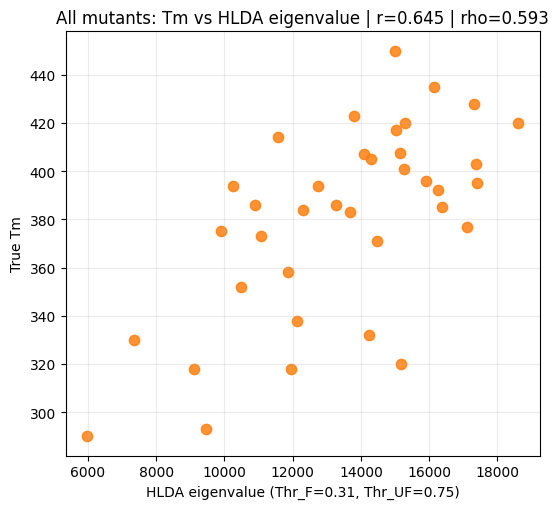

,mutant,Tm,EV
0,WT,407.0,14083.451
1,D2N,420.0,15303.283
2,D2A,394.0,12748.962
3,Y9E,290.0,5977.556
4,T7Q,403.0,17376.544
5,D2R,450.0,14989.126
6,T7R,395.0,17404.745
7,D2C,435.0,16143.259
8,Y9Q,352.0,10492.639
9,Y9G,358.0,11861.531


In [104]:
global_corr_df = baseline_df[['mutant', target_metric, 'EV']].copy()
global_stats = prediction_stats(global_corr_df.rename(columns={'EV': f'pred_{target_metric}'}), target_metric)
global_summary_df = pd.DataFrame([{
    'Thr_F': selected_thr_f,
    'Thr_UF': selected_thr_uf,
    'n_mutants': int(len(global_corr_df)),
    'pearson': global_stats['pearson'],
    'pearson_p': global_stats['pearson_p'],
    'spearman': global_stats['spearman'],
    'spearman_p': global_stats['spearman_p'],
}])
display(global_summary_df.round(4))

fig, ax = plt.subplots(figsize=(5.6, 5.2))
ax.scatter(global_corr_df['EV'], global_corr_df[target_metric], s=55, color='tab:orange', alpha=0.85)
ax.set_xlabel(f'HLDA eigenvalue (Thr_F={selected_thr_f:.2f}, Thr_UF={selected_thr_uf:.2f})')
ax.set_ylabel(f'True {target_metric}')
ax.set_title(f'All mutants: {target_metric} vs HLDA eigenvalue | r={global_stats["pearson"]:.3f} | rho={global_stats["spearman"]:.3f}')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

global_corr_df.round(3)



### Repeated Train/Test Linear Baseline


In [105]:
experiment_rows = []
prediction_frames = []
selected_threshold_rows = []

for run_idx in range(1, num_experiments + 1):
    run_seed = base_seed + run_idx - 1
    mutant_split_df = tm_df[['mutant', target_metric]].copy()
    train_tm_df, val_tm_df, test_tm_df = split_mutants_three_way(mutant_split_df, train_count=train_count, val_count=val_count, seed=run_seed)
    fit_tm_df = pd.concat([train_tm_df, val_tm_df], ignore_index=True)

    threshold_candidates = []
    for (thr_f, thr_uf), g in per_threshold_df.groupby(['Thr_F', 'Thr_UF']):
        fit_df = fit_tm_df.merge(g[['Mutant', 'EV']], left_on='mutant', right_on='Mutant', how='inner').dropna().reset_index(drop=True)
        test_df = test_tm_df.merge(g[['Mutant', 'EV']], left_on='mutant', right_on='Mutant', how='inner').dropna().reset_index(drop=True)
        if len(fit_df) < 3 or len(test_df) < 2:
            continue
        fit_stats_df = fit_df[['mutant', target_metric]].copy()
        fit_stats_df[f'pred_{target_metric}'] = fit_df['EV'].to_numpy(dtype=float)
        fit_stats = prediction_stats(fit_stats_df, target_metric)
        threshold_candidates.append({
            'Thr_F': float(thr_f),
            'Thr_UF': float(thr_uf),
            'fit_n': int(len(fit_df)),
            'fit_pearson': float(fit_stats['pearson']),
            'fit_spearman': float(fit_stats['spearman']),
            'abs_fit_pearson': abs(float(fit_stats['pearson'])),
            'abs_fit_spearman': abs(float(fit_stats['spearman'])),
        })
    threshold_candidates_df = pd.DataFrame(threshold_candidates).sort_values(['abs_fit_pearson', 'abs_fit_spearman'], ascending=[False, False]).reset_index(drop=True)
    best_threshold = threshold_candidates_df.iloc[0]
    selected_thr_f = float(best_threshold['Thr_F'])
    selected_thr_uf = float(best_threshold['Thr_UF'])

    fit_df = fit_tm_df.merge(
        per_threshold_df[(per_threshold_df['Thr_F'] == selected_thr_f) & (per_threshold_df['Thr_UF'] == selected_thr_uf)][['Mutant', 'EV']],
        left_on='mutant', right_on='Mutant', how='inner'
    ).dropna().reset_index(drop=True)
    test_df = test_tm_df.merge(
        per_threshold_df[(per_threshold_df['Thr_F'] == selected_thr_f) & (per_threshold_df['Thr_UF'] == selected_thr_uf)][['Mutant', 'EV']],
        left_on='mutant', right_on='Mutant', how='inner'
    ).dropna().reset_index(drop=True)

    coef = fit_linear_model(fit_df, feature_col='EV', target_col=target_metric)
    fit_pred_df = predict_linear_model(fit_df, coef, feature_col='EV', target_col=target_metric)
    test_pred_df = predict_linear_model(test_df, coef, feature_col='EV', target_col=target_metric)
    fit_stats = prediction_stats(fit_pred_df[['mutant', target_metric, f'pred_{target_metric}']], target_metric)
    test_stats = prediction_stats(test_pred_df[['mutant', target_metric, f'pred_{target_metric}']], target_metric)

    experiment_rows.append({
        'run_idx': run_idx,
        'run_seed': run_seed,
        'Thr_F': selected_thr_f,
        'Thr_UF': selected_thr_uf,
        'fit_n': int(len(fit_df)),
        'test_n': int(len(test_df)),
        'intercept': float(coef[0]),
        'slope': float(coef[1]),
        **{f'fit_{k}': v for k, v in fit_stats.items()},
        **{f'test_{k}': v for k, v in test_stats.items()},
    })
    selected_threshold_rows.append({
        'run_idx': run_idx,
        'run_seed': run_seed,
        'Thr_F': selected_thr_f,
        'Thr_UF': selected_thr_uf,
        'fit_pearson': best_threshold['fit_pearson'],
        'fit_spearman': best_threshold['fit_spearman'],
    })
    prediction_frames.append(test_pred_df.assign(run_idx=run_idx, run_seed=run_seed, Thr_F=selected_thr_f, Thr_UF=selected_thr_uf))

experiment_df = pd.DataFrame(experiment_rows).sort_values('test_rmse').reset_index(drop=True)
selected_threshold_df = pd.DataFrame(selected_threshold_rows).sort_values('run_idx').reset_index(drop=True)
all_test_predictions_df = pd.concat(prediction_frames, ignore_index=True)

display(selected_threshold_df.round(4))

display_cols = [
    'run_idx', 'run_seed', 'Thr_F', 'Thr_UF', 'fit_n', 'test_n', 'slope', 'intercept',
    'fit_rmse', 'fit_r2', 'fit_pearson', 'fit_spearman',
    'test_rmse', 'test_r2', 'test_pearson', 'test_spearman', 'test_pearson_p', 'test_spearman_p',
]
experiment_df[display_cols].round(4)



,run_idx,run_seed,Thr_F,Thr_UF,fit_pearson,fit_spearman
0,1,657567675657,0.33,0.77,0.7058,0.6653
1,2,657567675658,0.31,0.77,0.5414,0.4767
2,3,657567675659,0.31,0.75,0.6987,0.6445
3,4,657567675660,0.33,0.75,0.7320,0.6881
4,5,657567675661,0.31,0.77,0.6964,0.6348
5,6,657567675662,0.31,0.71,0.5369,0.5145
6,7,657567675663,0.33,0.77,0.6730,0.6646
7,8,657567675664,0.31,0.75,0.6908,0.5381
8,9,657567675665,0.29,0.81,0.6538,0.4886
9,10,657567675666,0.33,0.77,0.7371,0.7480


,run_idx,run_seed,Thr_F,Thr_UF,fit_n,test_n,slope,intercept,fit_rmse,fit_r2,fit_pearson,fit_spearman,test_rmse,test_r2,test_pearson,test_spearman,test_pearson_p,test_spearman_p
0,6,657567675662,0.31,0.71,22,15,0.0093,270.3218,33.7693,0.4934,0.5369,0.5145,25.0982,0.7889,0.7560,0.7918,0.0011,0.0004
1,3,657567675659,0.31,0.75,22,15,0.0091,250.6946,31.0883,0.7381,0.6987,0.6445,30.2395,0.3327,0.5766,0.4929,0.0244,0.0620
2,8,657567675664,0.31,0.75,22,15,0.0116,220.2277,31.6235,0.7267,0.6908,0.5381,31.2202,0.8768,0.6311,0.5702,0.0116,0.0265
3,9,657567675665,0.29,0.81,22,15,0.0067,263.1549,31.3994,0.6722,0.6538,0.4886,33.2252,0.3334,0.4864,0.6261,0.0660,0.0125
4,7,657567675663,0.33,0.77,22,15,0.0098,245.1793,29.1901,0.7006,0.6730,0.6646,33.7892,0.8192,0.6012,0.4107,0.0178,0.1283
5,1,657567675657,0.33,0.77,22,15,0.0080,261.5018,29.5441,0.7481,0.7058,0.6653,33.9089,0.1215,0.4740,0.4179,0.0742,0.1212
6,10,657567675666,0.33,0.77,22,15,0.0092,252.5410,28.1672,0.7915,0.7371,0.7480,34.3042,0.4371,0.3387,0.3179,0.2169,0.2483
7,4,657567675660,0.33,0.75,22,15,0.0094,262.2241,27.4353,0.7846,0.7320,0.6881,34.5079,0.4950,0.4863,0.4429,0.0660,0.0983
8,5,657567675661,0.31,0.77,22,15,0.0092,252.8705,27.7187,0.7347,0.6964,0.6348,34.9742,0.6201,0.5705,0.5147,0.0264,0.0496
9,2,657567675658,0.31,0.77,22,15,0.0075,285.4135,27.7400,0.5002,0.5414,0.4767,38.7022,0.3225,0.8280,0.8561,0.0001,0.0000


### Aggregate Test Performance


In [106]:
aggregate_df = pd.DataFrame([{
    'num_experiments': int(len(experiment_df)),
    'test_rmse_mean': experiment_df['test_rmse'].mean(),
    'test_rmse_std': experiment_df['test_rmse'].std(ddof=1) if len(experiment_df) > 1 else 0.0,
    'test_pearson_mean': experiment_df['test_pearson'].mean(),
    'test_pearson_std': experiment_df['test_pearson'].std(ddof=1) if len(experiment_df) > 1 else 0.0,
    'test_spearman_mean': experiment_df['test_spearman'].mean(),
    'test_spearman_std': experiment_df['test_spearman'].std(ddof=1) if len(experiment_df) > 1 else 0.0,
    'test_r2_mean': experiment_df['test_r2'].mean(),
    'test_r2_std': experiment_df['test_r2'].std(ddof=1) if len(experiment_df) > 1 else 0.0,
}])
aggregate_df.round(4)



,num_experiments,test_rmse_mean,test_rmse_std,test_pearson_mean,test_pearson_std,test_spearman_mean,test_spearman_std,test_r2_mean,test_r2_std
0,10,32.997,3.5764,0.5749,0.1424,0.5441,0.1715,0.5147,0.2526


### Best Run Scatter


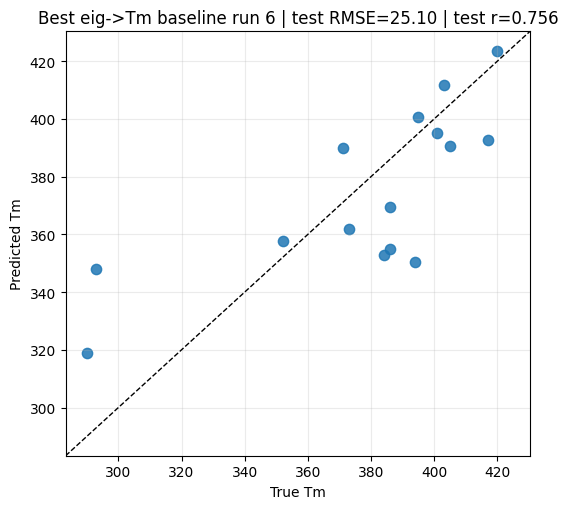

,mutant,Tm,EV,pred_Tm,run_idx,run_seed,Thr_F,Thr_UF
75,D2E,417.0,13172.213,392.591,6,657567675662,0.31,0.71
76,D2K,420.0,16518.231,423.650,6,657567675662,0.31,0.71
77,E4A,401.0,13436.781,395.047,6,657567675662,0.31,0.71
78,E4Y,405.0,12963.541,390.654,6,657567675662,0.31,0.71
79,T5G,394.0,8637.149,350.495,6,657567675662,0.31,0.71
80,T7Q,403.0,15247.749,411.857,6,657567675662,0.31,0.71
81,T7R,395.0,14029.944,400.553,6,657567675662,0.31,0.71
82,T7Y,386.0,10683.228,369.487,6,657567675662,0.31,0.71
83,Y0Q,371.0,12881.484,389.892,6,657567675662,0.31,0.71
84,Y9A,293.0,8365.711,347.975,6,657567675662,0.31,0.71


In [107]:
best_row = experiment_df.sort_values(['test_rmse', 'test_mae', 'test_r2'], ascending=[True, True, False]).iloc[0]
best_run_idx = int(best_row['run_idx'])
best_test_df = all_test_predictions_df[all_test_predictions_df['run_idx'] == best_run_idx].copy()

fig, ax = plt.subplots(figsize=(5.5, 5.2))
ax.scatter(best_test_df[target_metric], best_test_df[f'pred_{target_metric}'], s=55, color='tab:blue', alpha=0.85)
lims = [
    float(min(best_test_df[target_metric].min(), best_test_df[f'pred_{target_metric}'].min())),
    float(max(best_test_df[target_metric].max(), best_test_df[f'pred_{target_metric}'].max())),
]
pad = 0.05 * (lims[1] - lims[0] + 1e-8)
lims = [lims[0] - pad, lims[1] + pad]
ax.plot(lims, lims, color='black', linestyle='--', linewidth=1.0)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(f'True {target_metric}')
ax.set_ylabel(f'Predicted {target_metric}')
ax.set_title(f'Best eig->Tm baseline run {best_run_idx} | test RMSE={best_row["test_rmse"]:.2f} | test r={best_row["test_pearson"]:.3f}')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

best_test_df.round(3)



### Comparison Hook for 02c


In [108]:
cv_baseline_summary_path = Path('../results/chignolin_cv_tm_2stage/run/metric_prediction_summary.csv')
if cv_baseline_summary_path.exists():
    cv_df = pd.read_csv(cv_baseline_summary_path)
    linear_combo_df = cv_df[cv_df['decoder'].astype(str) == 'linear_combo'].copy()
    if not linear_combo_df.empty:
        comparison_df = pd.DataFrame([{
            'model': 'HLDA eigenvalue linear baseline',
            'test_rmse_mean': experiment_df['test_rmse'].mean(),
            'test_pearson_mean': experiment_df['test_pearson'].mean(),
            'test_spearman_mean': experiment_df['test_spearman'].mean(),
        }, {
            'model': '02c linear_combo',
            'test_rmse_mean': linear_combo_df['test_rmse'].mean(),
            'test_pearson_mean': linear_combo_df['test_pearson'].mean(),
            'test_spearman_mean': linear_combo_df['test_spearman'].mean(),
        }])
        display(comparison_df.round(4))
    else:
        print('02c summary found, but no linear_combo rows are present.')
else:
    print('02c metric_prediction_summary.csv not found; run 02c first if you want the direct comparison table.')



,model,test_rmse_mean,test_pearson_mean,test_spearman_mean
0,HLDA eigenvalue linear baseline,32.9970,0.5749,0.5441
1,02c linear_combo,40.5017,0.6133,0.4903
